# MATH 440: Rumor Spreading Activity

## Modeling Logistic Growth Through Random Contact

**Learning Goals:**
- Simulate the spread of a rumor through random contact
- Observe how wasted attempts create logistic (not exponential) growth
- Visualize the relationship between daily change and cumulative spread
- Connect simulation results to the logistic growth model

---
## Setup: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn
# Set random seed for reproducibility (optional - comment out for different results each run)
random.seed(42)
np.random.seed(42)

# # Configure plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

---

## Part 1: Simulate the Rumor Spreading

### The Rules

1. **Day 1**: One student (randomly chosen) knows the rumor
2. **Each subsequent day**: Every student who knows the rumor randomly selects ONE other student (from 1 to N) and attempts to tell them
3. **Success condition**: If the selected student doesn't know yet, they learn the rumor
4. **Wasted attempt**: If the selected student already knows, nothing happens
5. **Stopping condition**: Continue until all students know the rumor

In [2]:
# Parameters
N = 26  # Total number of students in the class

# Initialize tracking variables
students_who_know = set()  # Use a set to track who knows (efficient for lookups)
day = 0

# Data storage
days = []
random_numbers = []  # Store all random numbers generated each day
cumulative_know = []  # Number of students who know after each day
daily_change = []  # Number of NEW students who learned each day
attempts_made = []  # Total attempts made each day
wasted_attempts = []  # Attempts that hit students who already knew

# Day 1: Pick a random student to start
patient_zero = random.randint(1, N)
students_who_know.add(patient_zero)

days.append(1)
random_numbers.append([patient_zero])
cumulative_know.append(1)
daily_change.append(1)
attempts_made.append(0)  # No attempts yet, just patient zero
wasted_attempts.append(0)

print(f"Day 1: Student {patient_zero} learns the rumor")
print(f"Students who know: {sorted(students_who_know)}")
print()

Day 1: Student 21 learns the rumor
Students who know: [21]



In [3]:
# Simulate subsequent days
day = 2

while len(students_who_know) < N:
    # Each person who knows attempts to tell one random student
    num_spreaders = len(students_who_know)
    
    # Generate random targets (one per spreader)
    targets = [random.randint(1, N) for _ in range(num_spreaders)]
    
    # Track who learns this day
    new_learners = set()
    wasted_count = 0
    
    for target in targets:
        if target not in students_who_know:
            new_learners.add(target)
        else:
            wasted_count += 1
    
    # Update who knows
    students_who_know.update(new_learners)
    
    # Record data
    days.append(day)
    random_numbers.append(targets)
    cumulative_know.append(len(students_who_know))
    daily_change.append(len(new_learners))
    attempts_made.append(num_spreaders)
    wasted_attempts.append(wasted_count)
    
    print(f"Day {day}:")
    print(f"  Attempts: {num_spreaders} spreaders → random targets: {targets}")
    print(f"  New learners: {sorted(new_learners)} ({len(new_learners)} students)")
    print(f"  Wasted attempts: {wasted_count}")
    print(f"  Cumulative who know: {len(students_who_know)}")
    print()
    
    day += 1

print(f"\n🎉 Everyone knows the rumor by Day {day-1}!")

Day 2:
  Attempts: 1 spreaders → random targets: [4]
  New learners: [4] (1 students)
  Wasted attempts: 0
  Cumulative who know: 2

Day 3:
  Attempts: 2 spreaders → random targets: [1, 24]
  New learners: [1, 24] (2 students)
  Wasted attempts: 0
  Cumulative who know: 4

Day 4:
  Attempts: 4 spreaders → random targets: [9, 8, 8, 5]
  New learners: [5, 8, 9] (3 students)
  Wasted attempts: 0
  Cumulative who know: 7

Day 5:
  Attempts: 7 spreaders → random targets: [24, 4, 22, 24, 18, 3, 19]
  New learners: [3, 18, 19, 22] (4 students)
  Wasted attempts: 3
  Cumulative who know: 11

Day 6:
  Attempts: 11 spreaders → random targets: [14, 2, 1, 3, 7, 8, 17, 20, 1, 18, 7]
  New learners: [2, 7, 14, 17, 20] (5 students)
  Wasted attempts: 5
  Cumulative who know: 16

Day 7:
  Attempts: 16 spreaders → random targets: [23, 21, 23, 18, 14, 8, 15, 19, 9, 26, 1, 25, 26, 6, 23, 14]
  New learners: [6, 15, 23, 25, 26] (5 students)
  Wasted attempts: 8
  Cumulative who know: 21

Day 8:
  Attempts

---
## Part 2: Display Results in Table Format

In [4]:
# Print header
print("=" * 100)
print("RUMOR SPREADING ACTIVITY: SUMMARY TABLE")
print("=" * 100)
print(f"Class size: N = {N} students")
print(f"Total days until everyone knows: {len(days)} days")
print("=" * 100)
print()

# Print table header
print(f"{'Day':<6} {'Attempts':<10} {'Random Numbers':<35} {'New':<6} {'Wasted':<8} {'Cumulative':<12} {'Daily':<8}")
print(f"{'':6} {'Made':<10} {'Generated':<35} {'Learn':<6} {'Attempts':<8} {'Who Know':<12} {'Change':<8}")
print("-" * 100)

# Print data rows
for i in range(len(days)):
    day_num = days[i]
    attempts = attempts_made[i]
    randoms = random_numbers[i]
    
    # Format random numbers: show first 5, then "..." if more
    if len(randoms) <= 5:
        randoms_str = str(randoms)
    else:
        randoms_str = str(randoms[:5])[:-1] + f", ... ({len(randoms)} total)]"
    
    new = daily_change[i]
    wasted = wasted_attempts[i]
    cumul = cumulative_know[i]
    
    print(f"{day_num:<6} {attempts:<10} {randoms_str:<40} {new:<6} {wasted:<8} {cumul:<12} {new:<8}")

print("=" * 100)

RUMOR SPREADING ACTIVITY: SUMMARY TABLE
Class size: N = 26 students
Total days until everyone knows: 11 days

Day    Attempts   Random Numbers                      New    Wasted   Cumulative   Daily   
       Made       Generated                           Learn  Attempts Who Know     Change  
----------------------------------------------------------------------------------------------------
1      0          [21]                                     1      0        1            1       
2      1          [4]                                      1      0        2            1       
3      2          [1, 24]                                  2      0        4            2       
4      4          [9, 8, 8, 5]                             3      0        7            3       
5      7          [24, 4, 22, 24, 18, ... (7 total)]       4      3        11           4       
6      11         [14, 2, 1, 3, 7, ... (11 total)]         5      5        16           5       
7      16         [23, 

---
## Part 3: Visualize the Results

We'll create two plots:
1. **Daily Change** (number of new students learning each day) - this shows the **rate** of spreading
2. **Cumulative Total** (total number who know) - this shows the **S-curve** of logistic growth

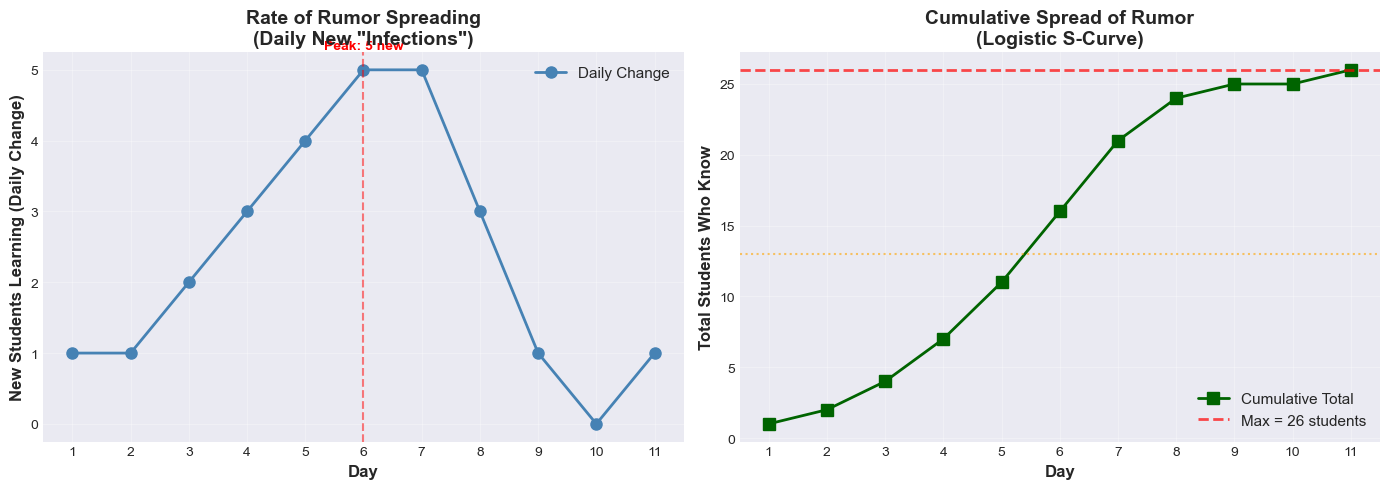

In [5]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Daily Change (Rate of Spreading)
ax1.plot(days, daily_change, 'o-', markersize=8, linewidth=2, color='steelblue', label='Daily Change')
ax1.set_xlabel('Day', fontsize=12, fontweight='bold')
ax1.set_ylabel('New Students Learning (Daily Change)', fontsize=12, fontweight='bold')
ax1.set_title('Rate of Rumor Spreading\n(Daily New "Infections")', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(days)
ax1.legend(fontsize=11)

# Highlight the peak
peak_day = days[np.argmax(daily_change)]
peak_value = max(daily_change)
ax1.axvline(peak_day, color='red', linestyle='--', alpha=0.5, label=f'Peak at Day {peak_day}')
ax1.text(peak_day, peak_value + 0.3, f'Peak: {peak_value} new', 
         ha='center', fontsize=10, color='red', fontweight='bold')

# Plot 2: Cumulative Total (S-Curve)
ax2.plot(days, cumulative_know, 's-', markersize=8, linewidth=2, color='darkgreen', label='Cumulative Total')
ax2.axhline(N, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Max = {N} students')
ax2.set_xlabel('Day', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Students Who Know', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Spread of Rumor\n(Logistic S-Curve)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(days)
ax2.legend(fontsize=11)

# Highlight when half the class knows (inflection point)
half_N = N / 2
ax2.axhline(half_N, color='orange', linestyle=':', alpha=0.6, label=f'Half class = {half_N}')

plt.tight_layout()
plt.show()

---
## Part 4: Combined View (Single Plot Option)

This plot shows the **Daily Change** (what students see in their activity chart).

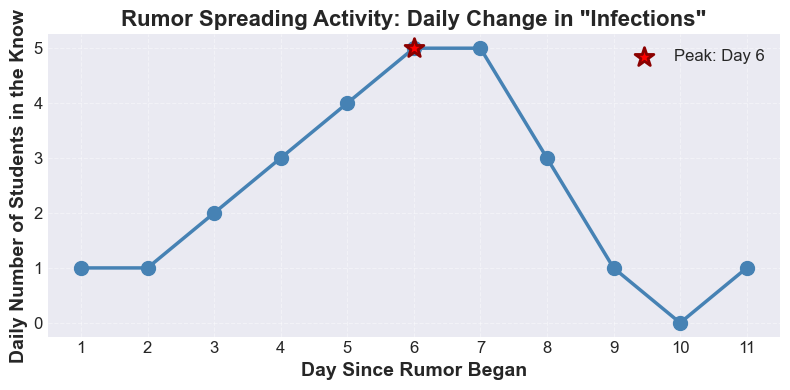

In [6]:
# Single focused plot on Daily Change (matches student worksheet)
plt.figure(figsize=(8,4))

plt.plot(days, daily_change, 'o-', markersize=10, linewidth=2.5, color='steelblue')

# Formatting
plt.xlabel('Day Since Rumor Began', fontsize=14, fontweight='bold')
plt.ylabel('Daily Number of Students in the Know', fontsize=14, fontweight='bold')
plt.title('Rumor Spreading Activity: Daily Change in "Infections"', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.4, linestyle='--')
plt.xticks(days, fontsize=12)
plt.yticks(fontsize=12)

# Highlight peak
peak_day = days[np.argmax(daily_change)]
peak_value = max(daily_change)
plt.scatter([peak_day], [peak_value], color='red', s=200, zorder=5, marker='*', 
            edgecolors='darkred', linewidths=2, label=f'Peak: Day {peak_day}')

plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

---
## Part 5: Analysis and Connection to Logistic Model

Let's verify that our data follows the logistic growth equation:

$$\Delta x = x_n \left(1 - \frac{x_n}{N}\right)$$

where:
- $\Delta x$ = daily change (new students learning)
- $x_n$ = number who already know at start of day $n$
- $N$ = total class size

In [7]:
# Compute predicted daily change using logistic formula
# Note: We use cumulative from PREVIOUS day (shift by 1)
predicted_change = []

for i in range(len(days)):
    if i == 0:
        # Day 1: starting condition (no prediction)
        predicted_change.append(np.nan)
    else:
        # Number who knew at START of this day = cumulative from previous day
        x_prev = cumulative_know[i-1]
        # Predicted new learners = x_prev * (1 - x_prev/N)
        predicted = x_prev * (1 - x_prev / N)
        predicted_change.append(predicted)

# Display comparison table
print("=" * 80)
print("COMPARISON: OBSERVED vs LOGISTIC MODEL PREDICTION")
print("=" * 80)
print(f"{'Day':<6} {'Who Knew':<12} {'Observed':<12} {'Predicted':<12} {'Error':<10}")
print(f"{'':6} {'(Start)':<12} {'New':<12} {'New':<12} {'(Obs-Pred)':<10}")
print("-" * 80)

for i in range(len(days)):
    if i == 0:
        print(f"{days[i]:<6} {0:<12} {daily_change[i]:<12} {'—':<12} {'—':<10}")
    else:
        who_knew = cumulative_know[i-1]
        obs = daily_change[i]
        pred = predicted_change[i]
        error = obs - pred
        print(f"{days[i]:<6} {who_knew:<12} {obs:<12} {pred:<12.2f} {error:<10.4f}")

print("=" * 80)
print("\nNote: Errors are due to randomness in the spreading process.")
print("The logistic model predicts the EXPECTED value; actual results vary.")

COMPARISON: OBSERVED vs LOGISTIC MODEL PREDICTION
Day    Who Knew     Observed     Predicted    Error     
       (Start)      New          New          (Obs-Pred)
--------------------------------------------------------------------------------
1      0            1            —            —         
2      1            1            0.96         0.0385    
3      2            2            1.85         0.1538    
4      4            3            3.38         -0.3846   
5      7            4            5.12         -1.1154   
6      11           5            6.35         -1.3462   
7      16           5            6.15         -1.1538   
8      21           3            4.04         -1.0385   
9      24           1            1.85         -0.8462   
10     25           0            0.96         -0.9615   
11     25           1            0.96         0.0385    

Note: Errors are due to randomness in the spreading process.
The logistic model predicts the EXPECTED value; actual results var

---
## Part 6: Visualize Model Fit

In [8]:
np.shape(who_knew)

()

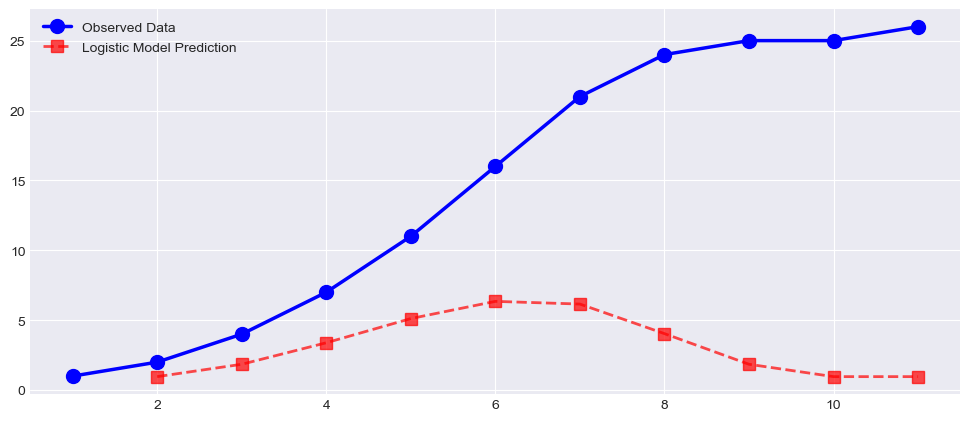

In [9]:
plt.figsize=(10,8)

plt.plot(days, cumulative_know, 'o-', markersize=10, linewidth=2.5, color='blue', label='Observed Data')
# plt.plot(days, new, 's--', markersize=8, linewidth=2, color='red', label='Logistic Model Prediction')

# plt.plot(days, daily_change[1:], 'o-', markersize=10, linewidth=2.5, 
#          color='steelblue', label='Observed Data')
plt.plot(days[1:], predicted_change[1:], 's--', markersize=8, linewidth=2, 
         color='red', alpha=0.7, label='Logistic Model Prediction')
plt.legend()
# Plot 2: Cumulative Total (S-Curve)
# ax2.plot(days, cumulative_know, 's-', markersize=8, linewidth=2, color='darkgreen', label='Cumulative Total')
# ax2.axhline(N, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Max = {N} students')
# ax2.set_xlabel('Day', fontsize=12, fontweight='bold')
# ax2.set_ylabel('Total Students Who Know', fontsize=12, fontweight='bold')
# ax2.set_title('Cumulative Spread of Rumor\n(Logistic S-Curve)', fontsize=14, fontweight='bold')
# ax2.grid(True, alpha=0.3)
# ax2.set_xticks(days)
# ax2.legend(fontsize=11)

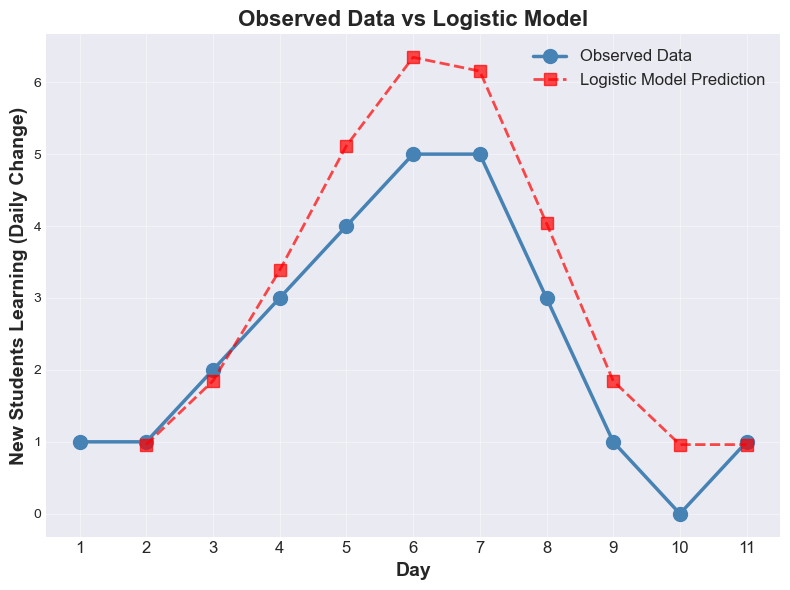

In [10]:
# Plot observed vs predicted daily change
plt.figure(figsize=(8, 6))

plt.plot(days, daily_change, 'o-', markersize=10, linewidth=2.5, 
         color='steelblue', label='Observed Data')
plt.plot(days, predicted_change, 's--', markersize=8, linewidth=2, 
         color='red', alpha=0.7, label='Logistic Model Prediction')

plt.xlabel('Day', fontsize=14, fontweight='bold')
plt.ylabel('New Students Learning (Daily Change)', fontsize=14, fontweight='bold')
plt.title('Observed Data vs Logistic Model', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12, loc='upper right')
plt.xticks(days, fontsize=12)
plt.tight_layout()
plt.show()

---
## Reflective Questions

Answer the following questions based on your observations:

### Question 1: Shape of the Graph
**Describe the shape of the graph (Daily Change vs Day) and how it relates to the rate at which the rumor spread during the activity.**

*Your answer here:*



---

### Question 2: Leveling Off
**Why does the Daily Change graph eventually decrease and approach zero as the number of days increases?**

*Hint: Think about what happens when most students already know the rumor. What happens to the spreading attempts?*

*Your answer here:*



---

### Question 3: Connection to the Data Table
**How does the shape of the Daily Change graph reflect what you see in the "Daily Change" column of your data table?**

*Your answer here:*



---

### Question 4: Peak Spreading Rate
**On which day did the rumor spread fastest (maximum daily change)? How many students knew the rumor at the START of that day? What fraction of the class is this?**

*Your answer here:*



---

### Question 5: Wasted Attempts
**Look at the "Wasted Attempts" column in your data. How does the number of wasted attempts change over time? Why does this happen?**

*Your answer here:*



---

### Question 6: Exponential vs Logistic
**If there were NO wasted attempts (i.e., every spreading attempt was successful), how would the graph look different? Would it still level off?**

*Your answer here:*



---

### Question 7: Real-World Application
**This model could represent the spread of a disease, a viral video, or adoption of a new technology. Give one real-world scenario where logistic growth (not exponential) would be expected. Explain why.**

*Your answer here:*




---
## Extension: Run Multiple Simulations

Since the spreading is random, each run will produce different results. Let's run the simulation 100 times and look at the average behavior.

Running 100 simulations...


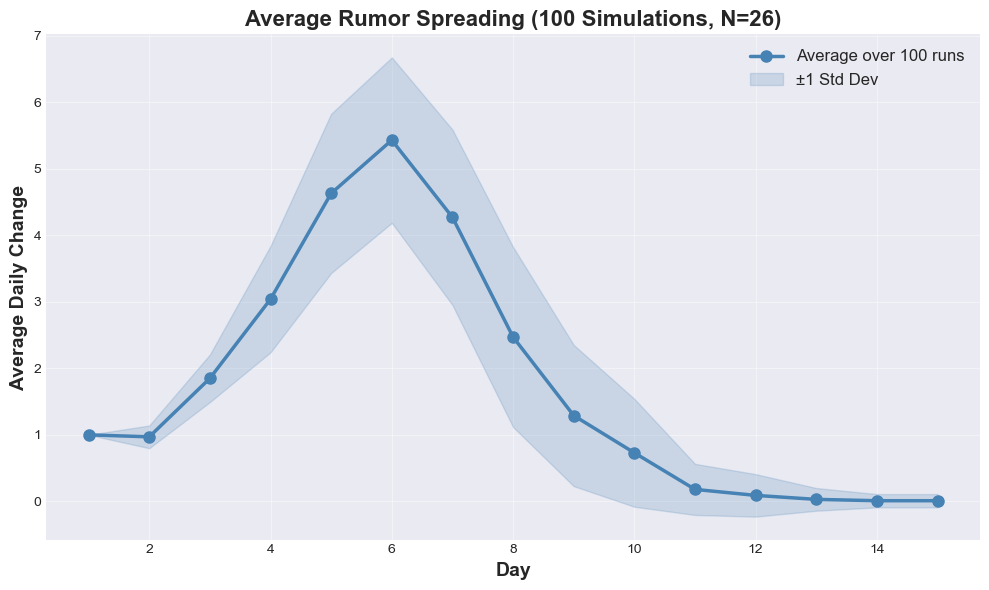


Average number of days to full spread: 10.1
Std deviation: 1.4 days


In [11]:
def simulate_rumor_spreading(N, max_days=20):
    """
    Simulate rumor spreading for a class of N students.
    Returns: (days, cumulative_know, daily_change)
    """
    students_who_know = set([random.randint(1, N)])
    
    days = [1]
    cumulative = [1]
    daily = [1]
    
    day = 2
    while len(students_who_know) < N and day <= max_days:
        num_spreaders = len(students_who_know)
        targets = [random.randint(1, N) for _ in range(num_spreaders)]
        
        new_learners = set()
        for target in targets:
            if target not in students_who_know:
                new_learners.add(target)
        
        students_who_know.update(new_learners)
        
        days.append(day)
        cumulative.append(len(students_who_know))
        daily.append(len(new_learners))
        
        day += 1
    
    return days, cumulative, daily

# Run 100 simulations
num_simulations = 100
all_daily_changes = []

print(f"Running {num_simulations} simulations...")
for i in range(num_simulations):
    days_sim, cumul_sim, daily_sim = simulate_rumor_spreading(N)
    all_daily_changes.append(daily_sim)

# Find max length to align arrays
max_len = max(len(dc) for dc in all_daily_changes)

# Pad shorter simulations with 0 (no new learners after everyone knows)
padded_daily = []
for dc in all_daily_changes:
    padded = dc + [0] * (max_len - len(dc))
    padded_daily.append(padded)

# Compute mean and std
mean_daily = np.mean(padded_daily, axis=0)
std_daily = np.std(padded_daily, axis=0)

days_plot = list(range(1, max_len + 1))

# Plot
plt.figure(figsize=(10, 6))

# Plot mean with shaded error region
plt.plot(days_plot, mean_daily, 'o-', markersize=8, linewidth=2.5, 
         color='steelblue', label=f'Average over {num_simulations} runs')
plt.fill_between(days_plot, 
                 mean_daily - std_daily, 
                 mean_daily + std_daily, 
                 color='steelblue', alpha=0.2, label='±1 Std Dev')

plt.xlabel('Day', fontsize=14, fontweight='bold')
plt.ylabel('Average Daily Change', fontsize=14, fontweight='bold')
plt.title(f'Average Rumor Spreading ({num_simulations} Simulations, N={N})', 
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nAverage number of days to full spread: {np.mean([len(dc) for dc in all_daily_changes]):.1f}")
print(f"Std deviation: {np.std([len(dc) for dc in all_daily_changes]):.1f} days")

---
## Summary

**Key Takeaways:**

1. **Random contact creates logistic growth**: When spreaders randomly select targets, wasted attempts naturally slow down the spread

2. **Daily change shows a bell curve**: The rate of new "infections" rises, peaks, then falls

3. **Peak occurs near N/2**: Maximum spreading happens when about half the class knows

4. **Wasted attempts increase over time**: As saturation approaches, most attempts hit people who already know

5. **Logistic equation emerges from simple rules**: The model $\Delta x = x(1 - x/N)$ predicts the observed pattern

This is the foundation for understanding epidemic models, technology adoption, and other processes with limited growth!

## Maybe find a way to use CNN on this 